In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
!pip -q install kagglehub

import kagglehub
import os

path = kagglehub.dataset_download("ahmedaliraja/unlabelled-dataset")

print("Dataset downloaded to:")
print(path)

print("\nFiles:")
print(os.listdir(path))

100%|██████████| 763/763 [00:00<00:00, 1.45MB/s]

Extracting files...
Dataset downloaded to:
/root/.cache/kagglehub/datasets/ahmedaliraja/unlabelled-dataset/versions/1

Files:
['Unlabelled_dataset.csv']


### **Load and inspect the dataset**

In [ ]:
file_path = path + "/Unlabelled_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
df.info()

Dataset Shape: (1166, 5)

Column Names:
['5.1', '3.5', '1.4', '0.2', 'Unnamed: 4']

First 5 Rows:


,5.1,3.5,1.4,0.2,Unnamed: 4
0,4.9,3.0,1.4,0.2,NaN
1,4.7,3.2,1.3,0.2,NaN
2,4.6,3.1,1.5,0.2,NaN
3,5.0,3.6,1.4,0.2,NaN
4,5.4,3.9,1.7,0.4,NaN



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1166 entries, 0 to 1165
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   5.1         1156 non-null   float64
 1   3.5         1157 non-null   float64
 2   1.4         1161 non-null   float64
 3   0.2         1162 non-null   float64
 4   Unnamed: 4  0 non-null      float64
dtypes: float64(5)
memory usage: 45.7 KB


### **Reload dataset correctly**

In [ ]:
# Reload dataset without treating the first row as column names
df = pd.read_csv(file_path, header=None)

print("Dataset Shape:", df.shape)

print("\nFirst 10 rows:")
display(df.head(10))

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Dataset Shape: (1167, 5)

First 10 rows:


,0,1,2,3,4
0,5.1,3.5,1.4,0.2,NaN
1,4.9,3.0,1.4,0.2,NaN
2,4.7,3.2,1.3,0.2,NaN
3,4.6,3.1,1.5,0.2,NaN
4,5.0,3.6,1.4,0.2,NaN
5,5.4,3.9,1.7,0.4,NaN
6,4.6,3.4,1.4,0.3,NaN
7,5.0,3.4,1.5,0.2,NaN
8,4.4,2.9,1.4,0.2,NaN
9,4.9,3.1,1.5,0.1,NaN



Data types:
0    float64
1    float64
2    float64
3    float64
4    float64
dtype: object

Missing values:
0      10
1       9
2       5
3       4
4    1167
dtype: int64


### **Clean and standardize the data**

In [ ]:
# Keep only the 4 useful features
X = df.iloc[:, :4].copy()

# Fill missing values with the median of each column
X = X.fillna(X.median())

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original data shape:", X.shape)
print("Scaled data shape:", X_scaled.shape)

print("\nMissing values after cleaning:")
print(X.isnull().sum())

print("\nFirst 5 scaled rows:")
print(X_scaled[:5])

Original data shape: (1167, 4)
Scaled data shape: (1167, 4)

Missing values after cleaning:
0    0
1    0
2    0
3    0
dtype: int64

First 5 scaled rows:
[[ 0.15644145 -0.69718784 -0.85098347 -0.88913162]
 [-0.33301477 -1.28235629 -0.85098347 -0.88913162]
 [-0.82247099 -1.04828891 -0.94850853 -0.88913162]
 [-1.0671991  -1.1653226  -0.75345841 -0.88913162]
 [-0.08828666 -0.58015415 -0.85098347 -0.88913162]]


### **Apply K-Means for different values of K**

In [ ]:
wcss = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

print("K values:", list(range(2, 11)))
print("WCSS values:")

for k, value in zip(range(2, 11), wcss):
    print(f"K = {k}: {value:.2f}")

K values: [2, 3, 4, 5, 6, 7, 8, 9, 10]
WCSS values:
K = 2: 1523.68
K = 3: 1035.42
K = 4: 627.30
K = 5: 489.53
K = 6: 395.33
K = 7: 322.92
K = 8: 279.58
K = 9: 250.00
K = 10: 218.25


### **Elbow Method**

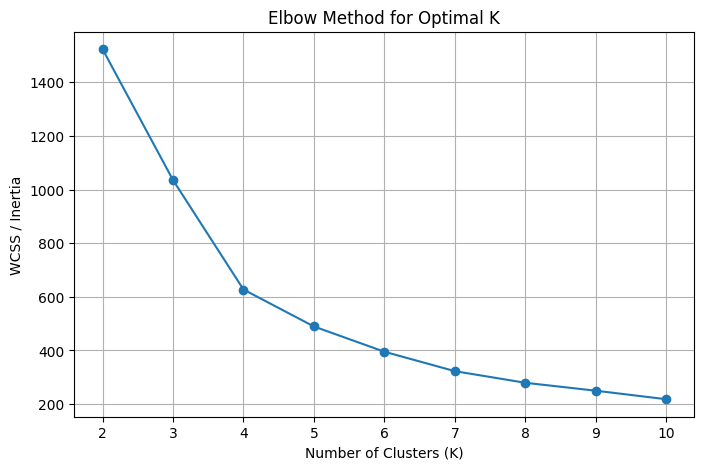

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), wcss, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method for Optimal K")

plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

### **Calculate Silhouette Scores**

In [ ]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

print("Silhouette Scores:")

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: {score:.4f}")

Silhouette Scores:
K = 2: 0.6192
K = 3: 0.5395
K = 4: 0.5437
K = 5: 0.5059
K = 6: 0.4662
K = 7: 0.4895
K = 8: 0.4922
K = 9: 0.4920
K = 10: 0.5042


### **Silhouette Score Plot**

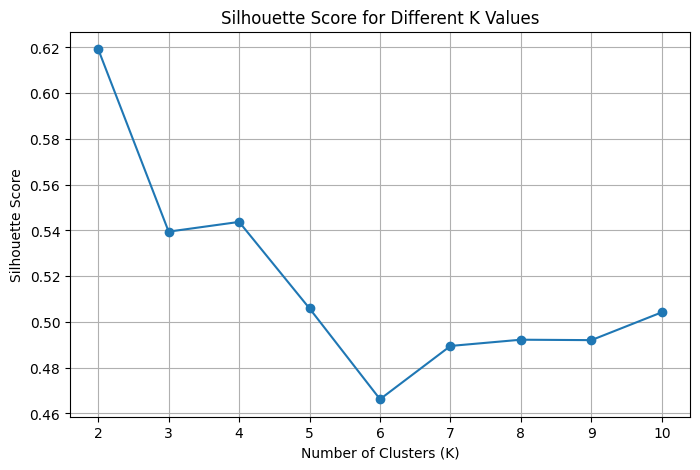

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), silhouette_scores, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

### **Train the final K-Means model**

In [ ]:
# Final number of clusters
final_k = 2

# Train final K-Means model
kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

# Generate cluster labels
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to the original cleaned data
df_clustered = X.copy()
df_clustered["Cluster"] = cluster_labels

print("Final K:", final_k)
print("Final Inertia:", kmeans_final.inertia_)

print("\nCluster counts:")
print(df_clustered["Cluster"].value_counts().sort_index())

print("\nFirst 10 rows with cluster labels:")
display(df_clustered.head(10))

Final K: 2
Final Inertia: 1523.6777843994673

Cluster counts:
Cluster
0    678
1    489
Name: count, dtype: int64

First 10 rows with cluster labels:


,0,1,2,3,Cluster
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


### **Apply PCA**

In [ ]:
# Reduce the 4 standardized features to 2 principal components
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original feature shape:", X_scaled.shape)
print("PCA shape:", X_pca.shape)

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal variance explained by 2 components:",
      pca.explained_variance_ratio_.sum())

Original feature shape: (1167, 4)
PCA shape: (1167, 2)

Explained variance ratio:
[0.72709534 0.24447542]

Total variance explained by 2 components: 0.9715707569331757


### **Final PCA Scatter Plot**

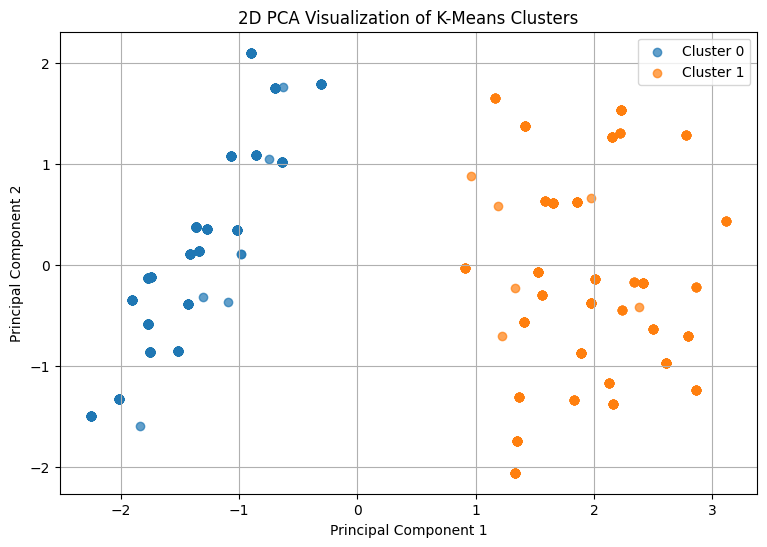

In [ ]:
plt.figure(figsize=(9, 6))

# Plot each cluster separately
for cluster in sorted(df_clustered["Cluster"].unique()):
    plt.scatter(
        X_pca[df_clustered["Cluster"] == cluster, 0],
        X_pca[df_clustered["Cluster"] == cluster, 1],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Visualization of K-Means Clusters")

plt.legend()
plt.grid(True)
plt.show()